In [160]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier

In [161]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

In [162]:
import pandas as pd
df = pd.read_excel("C:/Users/DELL/Documents/VEMV/business/work/DETECTION_DE_FRAUDES_FISCALES/data/raw/Données_Marchés_publics_2024.xlsx")
data = df.copy()
data.head()

,ident,Type_de_centre,Regime,Persojuri,gctax (groupe de compte de gestion des contribuables),Type de déclarant des MP dans les DSF,MinCA19,Conformité de déclaration de marchés en 2019,Conformité de déclaration de marchés en 2020,Conformité de déclaration de marchés en 2021,Conformité de déclaration de marchés en 2022,Conformité de déclaration de marchés en 2023,MinCA20,MinCA21,MinCA22,MinCA23,MinCA19_23,Nbprestation_marchés,Typedemarché,Actif2024,Comportement déclaratif dans les DSF par rapport au cumul mensuel en 2024,SBTP,SERM,SFBME,SPSOE,STLM,Fraude
0,1,DGE,IGS,Morale,Petits comptes,Déclarants permanents,Oui,MND,MD,MD,MD,MD,Non,Non,Non,Non,Non,Plus de deux marchés,Bons_commande,Oui,Bonne déclaration,Oui,Oui,Oui,Oui,Oui,Risque faible
1,2,DGE,IGS,Morale,Petits comptes,Déclarants permanents,Oui,MND,MD,MD,MD,MD,Non,Non,Non,Non,Non,Plus de deux marchés,Bons_commande,Oui,Mauvaise déclaration,Oui,Non,Oui,Oui,Non,Pas de risque
2,3,DGE,IGS,Morale,Petits comptes,Déclarants permanents,Non,MD,NPC,NPC,MD,NPC,Non,Non,Non,Non,Non,Un marché,Lettre_commande&Marchés,Oui,Mauvaise déclaration,Non,Non,Oui,Non,Non,Pas de risque
3,4,DGE,IGS,Morale,Petits comptes,Déclarants permanents,Non,MD,NPC,NPC,MD,NPC,Non,Non,Non,Non,Non,Un marché,Lettre_commande&Marchés,Oui,Mauvaise déclaration,Oui,Non,Non,Non,Non,Pas de risque
4,5,DGE,IGS,Morale,Petits comptes,Déclarants permanents,Non,MD,NPC,NPC,NPC,MD,Non,Non,Non,Non,Non,Un marché,Lettre_commande&Marchés,Oui,Mauvaise déclaration,Non,Non,Non,Non,Oui,Pas de risque


In [164]:
data.drop(['Comportement déclaratif dans les DSF par rapport au cumul mensuel en 2024', 'ident', 'Type_de_centre',
           'Conformité de déclaration de marchés en 2019', 'Conformité de déclaration de marchés en 2020',
           'Conformité de déclaration de marchés en 2021', 'Conformité de déclaration de marchés en 2022',
           'Conformité de déclaration de marchés en 2023', 'SBTP', 'SERM', 'SFBME', 'SPSOE', 'STLM'], axis=1, inplace=True)

In [41]:
colonnes_binaires = ['Regime', 'Persojuri', 'MinCA19', 'MinCA20', 'MinCA21', 'MinCA22', 'MinCA23', 'MinCA19_23', 'Actif2024', 'SBTP', 'SERM', 'SFBME', 'SPSOE', 'STLM', 'gctax (groupe de compte de gestion des contribuables)', 'Type de déclarant des MP dans les DSF']

colonnes_multimodales = ['Conformité de déclaration de marchés en 2019', 'Conformité de déclaration de marchés en 2020', 'Conformité de déclaration de marchés en 2021', 'Conformité de déclaration de marchés en 2022', 'Conformité de déclaration de marchés en 2023', 'Nbprestation_marchés', 'Typedemarché']


In [42]:
len(colonnes_binaires)

16

In [ ]:
data[data['Fraude'] == 'Risque faible'] = 'Risqué'
data[data['Fraude'] == 'Risque élevé'] = 'Risqué'

In [43]:
data.columns

Index(['Regime', 'Persojuri',
       'gctax (groupe de compte de gestion des contribuables)',
       'Type de déclarant des MP dans les DSF', 'MinCA19',
       'Conformité de déclaration de marchés en 2019',
       'Conformité de déclaration de marchés en 2020',
       'Conformité de déclaration de marchés en 2021',
       'Conformité de déclaration de marchés en 2022',
       'Conformité de déclaration de marchés en 2023', 'MinCA20', 'MinCA21',
       'MinCA22', 'MinCA23', 'MinCA19_23', 'Nbprestation_marchés',
       'Typedemarché', 'Actif2024', 'SBTP', 'SERM', 'SFBME', 'SPSOE', 'STLM',
       'Fraude'],
      dtype='object')

In [ ]:
#cols_to_drop = 

In [126]:
# Division
from sklearn.model_selection import train_test_split

def split(data):
    X = data.drop('Fraude', axis=1)
    y = data['Fraude']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)
    
    return X_train, X_test, y_train, y_test

In [127]:
X_train, X_test, y_train, y_test = split(data)

In [128]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(9438, 23)
(2360, 23)
(9438,)
(2360,)


In [129]:
y_test.value_counts(normalize=True)

Fraude
Pas de risque    0.483898
Risque élevé     0.320339
Risque faible    0.195763
Name: proportion, dtype: float64

In [130]:
y_train.value_counts(normalize=True)

Fraude
Pas de risque    0.483895
Risque élevé     0.320407
Risque faible    0.195698
Name: proportion, dtype: float64

In [131]:
classifier = DecisionTreeClassifier()

preprocessor = ColumnTransformer(
    transformers=[
        ('binary_cols', OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), colonnes_binaires),
        ('multimodal_cols', OneHotEncoder(handle_unknown="ignore", sparse_output=False), colonnes_multimodales),
    ],
    verbose_feature_names_out=False,
).set_output(transform="pandas")

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier

In [ ]:
# Initialisation de l'estimateur
cb = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', CatBoostClassifier())
])

lr = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', LogisticRegression(multi_class='multinomial'))
])

xgb = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', XGBClassifier())
])

rf = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', RandomForestClassifier())
])

In [ ]:
models = {
    "Decision Tree": cb,
    "Linear Regression": lr,
    "Xgboost": xgb,
    "Randam Forest": rf
}

In [152]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, cohen_kappa_score, roc_auc_score, roc_curve, f1_score
from sklearn.model_selection import learning_curve

In [153]:
def evaluation(model, X_train, X_test, y_train, y_test):

    # Entrainement 
    model.fit(X_train, y_train)
    
    # predictions
    y_pred = model.predict(X_test)

    kappa = cohen_kappa_score(y_test, y_pred)
    #auc = roc_auc_score(y_test, y_pred)

    # evaluation
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print(f"cohen's kappa:-------> {kappa}")
    #print(f"AUC------------------> {auc}")


    # Courbe d'apprentissage
    N, trainscore, valscore = learning_curve(model, X_train, y_train, cv=4, scoring='f1_weighted', train_sizes=[0.25, 0.50, 0.75, 1.00])

    plt.figure()
    plt.plot(N, trainscore.mean(axis=1), label='Entrainement')
    plt.plot(N, valscore.mean(axis=1), label='Validation')
    plt.xlabel("Taille des données d'entrainement")
    plt.ylabel("f1_score")
    plt.legend()
    plt.show()

In [135]:
# Encodage de la variable cible

dico = {
    "pas de risque": 0,
    "risque faible": 1,
    "risque élevé": 2
}
y_train = y_train.str.strip().str.lower().map(dico)


In [136]:
y_test = y_test.str.strip().str.lower().map(dico)

========================Decision Tree=====================================
[[802 130 210]
 [196 114 152]
 [275 122 359]]
              precision    recall  f1-score   support

           0       0.63      0.70      0.66      1142
           1       0.31      0.25      0.28       462
           2       0.50      0.47      0.49       756

    accuracy                           0.54      2360
   macro avg       0.48      0.47      0.48      2360
weighted avg       0.53      0.54      0.53      2360

cohen's kappa:-------> 0.24725119985324828


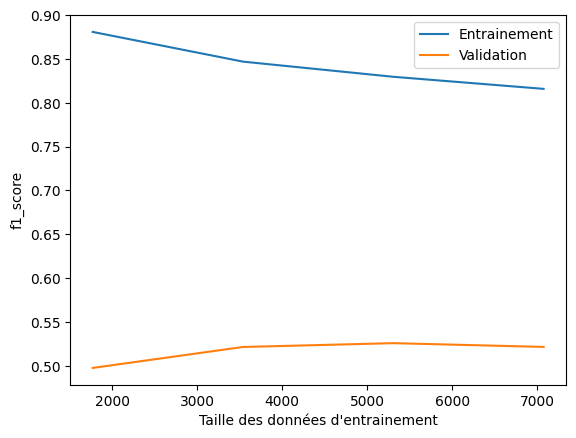

========================Linear Regression=====================================


c:\Users\DELL\Documents\VEMV\business\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[[920  50 172]
 [227  49 186]
 [287  50 419]]
              precision    recall  f1-score   support

           0       0.64      0.81      0.71      1142
           1       0.33      0.11      0.16       462
           2       0.54      0.55      0.55       756

    accuracy                           0.59      2360
   macro avg       0.50      0.49      0.47      2360
weighted avg       0.55      0.59      0.55      2360

cohen's kappa:-------> 0.29972079437754495


c:\Users\DELL\Documents\VEMV\business\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\DELL\Documents\VEMV\business\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\DELL\Documents\VEMV\business\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\DELL\Documents\VEMV\business\lib\site-packages\sklearn\linear_model\_logistic.py:1247: F

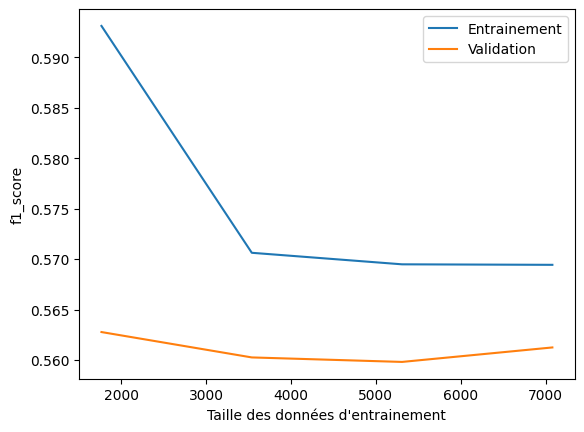

========================Xgboost=====================================
[[882  68 192]
 [208  83 171]
 [246  98 412]]
              precision    recall  f1-score   support

           0       0.66      0.77      0.71      1142
           1       0.33      0.18      0.23       462
           2       0.53      0.54      0.54       756

    accuracy                           0.58      2360
   macro avg       0.51      0.50      0.49      2360
weighted avg       0.56      0.58      0.56      2360

cohen's kappa:-------> 0.30603808013879963


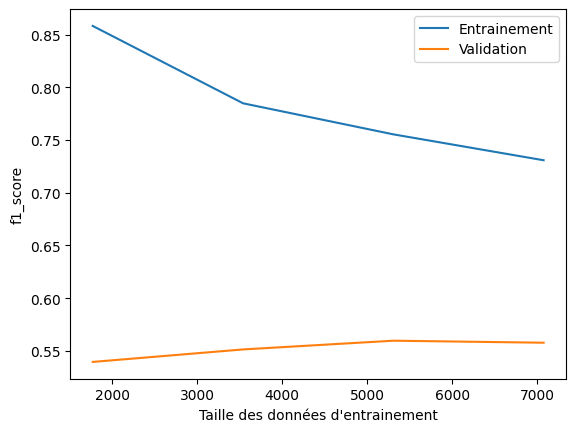

========================Randam Forest=====================================
[[852  83 207]
 [189 109 164]
 [258 102 396]]
              precision    recall  f1-score   support

           0       0.66      0.75      0.70      1142
           1       0.37      0.24      0.29       462
           2       0.52      0.52      0.52       756

    accuracy                           0.57      2360
   macro avg       0.51      0.50      0.50      2360
weighted avg       0.56      0.57      0.56      2360

cohen's kappa:-------> 0.2976986537750611


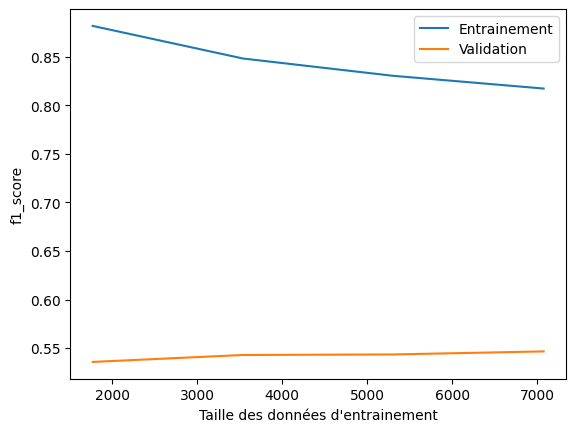

In [159]:
for name, model in models.items():
    print(f'========================{name}=====================================')
    evaluation(model, X_train, X_test, y_train, y_test)

In [148]:
import seaborn as sns

C:\Users\DELL\AppData\Local\Temp\ipykernel_42984\1315396732.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


<Axes: xlabel='Importance', ylabel='Feature'>

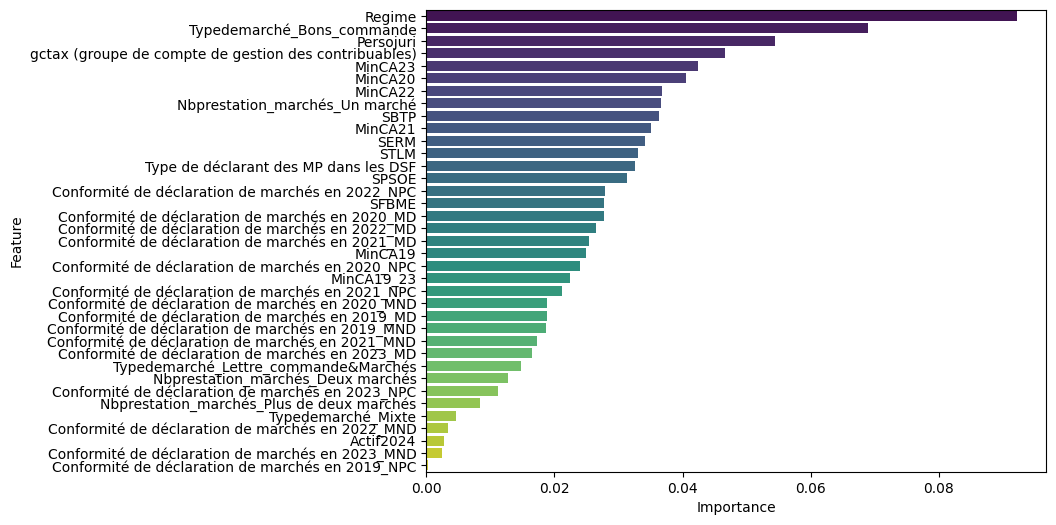

In [149]:
# importance des variables
classifier = model.named_steps['classifier']

importances = classifier.feature_importances_
# Récupérer le ColumnTransformer
preprocessor = model.named_steps['preprocessing']

# Obtenir les noms des features après transformation
names = preprocessor.get_feature_names_out()

df_importances = pd.DataFrame({
    "Feature": names,
    "Importance": importances
})

# Trier par importance décroissante
df_importances = df_importances.sort_values(by="Importance", ascending=False)

# Barplot classé
plt.figure(figsize=(8,6))
sns.barplot(
    data=df_importances,
    x="Importance", 
    y="Feature", 
    palette="viridis"
)